# 03 — Backtesting without fooling yourself

A backtest is only worth anything if it could have been traded in real time. The two ways it lies are
**look-ahead** (using information you would not have had) and **ignored costs**. This notebook builds the
backtest around avoiding both, and runs it walk-forward — fitting on the past and trading the future — on
MA/V.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from statarb import data, backtest, signals

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
BLUE, GREEN, GREY = "#0072B2", "#009E73", "#8A8F98"
px = data.align_prices(pd.read_csv("../data/pairs.csv", index_col=0, parse_dates=True))
y, x = np.log(px["MA"]), np.log(px["V"])

## The no-look-ahead convention

A position chosen at the close of day $t$ earns the spread's move over the **next** day. So PnL uses the
*lagged* position:
$$\text{gross}_t = \text{pos}_{t-1}\,(s_t - s_{t-1}).$$
Letting today's position earn today's move would be look-ahead — it silently assumes you traded on
information you only had at the close. That one lag is the difference between a tradeable curve and a
fantasy.

## Costs on turnover

Every change in position pays a cost. Turnover is $|\text{pos}_t - \text{pos}_{t-1}|$ (a flat→±1 entry
costs one unit, a +1→−1 flip costs two), and the net PnL subtracts `cost` times that turnover. Costs are
what separate a signal that looks good on paper from one that survives trading.

In [2]:
# performance_stats summarises a PnL stream; turnover/costs are applied inside strategy_returns.
s = signals.spread(y, x)
pos = signals.generate_signals(signals.zscore(s).reset_index(drop=True), 1.5, 0.5); pos.index = s.index
gross = backtest.strategy_returns(pos, s, cost=0.0)
net = backtest.strategy_returns(pos, s, cost=0.0005)
print(f"gross total PnL: {gross.sum():.3f}   net of costs: {net.sum():.3f}   cost drag: {gross.sum()-net.sum():.3f}")

gross total PnL: 0.454   net of costs: 0.448   cost drag: 0.006


## Walk-forward, out-of-sample

The real test rolls a fixed training window forward: on each block, estimate $\beta$ and the spread's
mean/std on the **train** window, standardise and trade the **next** block with those fixed parameters,
then slide forward. Because every trade uses only data from before it, the concatenated result is a
genuine out-of-sample track record. `walk_forward` handles the roll and returns the PnL, equity, and
summary statistics.

folds: 44   OOS days: 2767
annualized Sharpe: 1.26
max drawdown: -0.100   hit rate: 52%


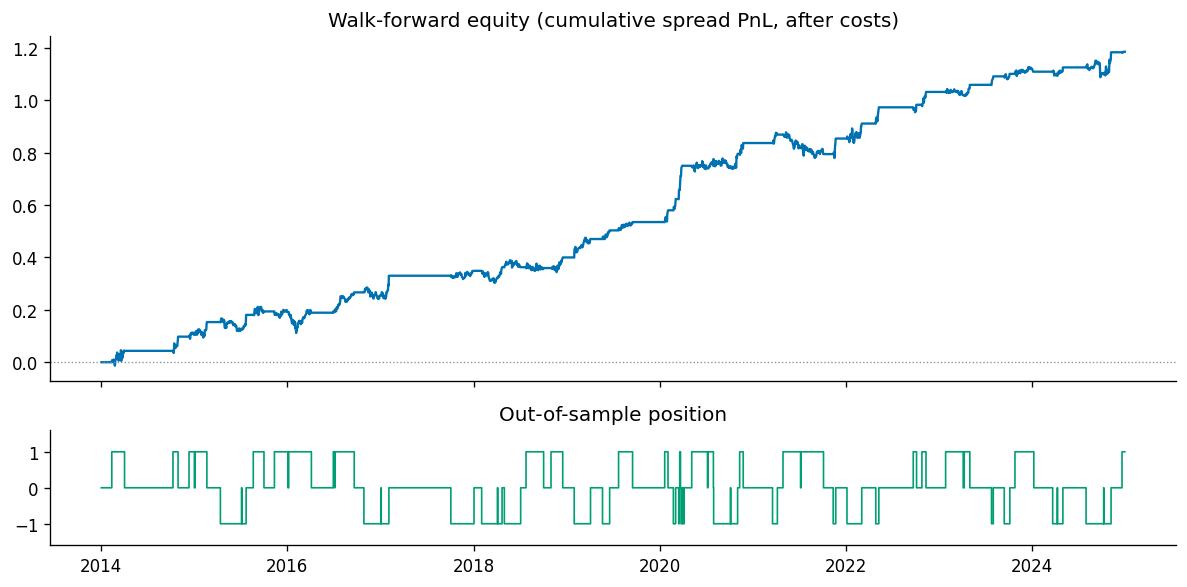

In [3]:
res = backtest.walk_forward(y, x, train=252, step=63, entry=1.5, exit=0.0, cost=0.0005)
st = res["stats"]
print(f"folds: {res['n_folds']}   OOS days: {st['n_periods']}")
print(f"annualized Sharpe: {st['sharpe']:.2f}")
print(f"max drawdown: {st['max_drawdown']:.3f}   hit rate: {st['hit_rate']*100:.0f}%")

fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
a1.plot(res["equity"].index, res["equity"], color=BLUE, lw=1.4)
a1.axhline(0, ls=":", color=GREY, lw=0.8); a1.set_title("Walk-forward equity (cumulative spread PnL, after costs)")
a2.plot(res["positions"].index, res["positions"], drawstyle="steps-post", color=GREEN, lw=1.0)
a2.set_ylim(-1.6, 1.6); a2.set_yticks([-1, 0, 1]); a2.set_title("Out-of-sample position")
plt.tight_layout(); plt.show()

The Sharpe here looks good — but a good-looking Sharpe from a single pair is not yet evidence of an
edge. It could be sampling noise, or the product of having searched many pairs. Quantifying that is the
job of the significance tests in the next notebook.